In [28]:
from scipy import stats
import numpy as np
import pandas as pd
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns
from fitter import Fitter, get_common_distributions, get_distributions
from matplotlib.pyplot import figure

In [29]:
path= 'C:\\Users\\Handwriting\\Desktop\\Dheeraj\\HEMI\\Main_Files\\Large_Carbon\\'

In [30]:
files_list= os.listdir('C:\\Users\\Handwriting\\Desktop\\Dheeraj\\HEMI\\Main_Files\\Large_Carbon\\')
files_list

['63020A_IP_09_05_27_2022',
 '63020A_TP07_05_27_2022',
 '63020B_IP08_01_07_2022',
 '63020B_TP08_05_27_2022',
 'Goodness_of_Fit_Large_Carbon']

In [32]:
carbon_type= files_list[0]
carbon_type

'63020A_IP_09_05_27_2022'

In [5]:
new_path= path+'\\'+carbon_type+'\\'+'Stacked_Excel_File_MA_AR_'
my_files= os.listdir(new_path)
my_files

['Stacked_MA_AR_Cir_61620B_TP.csv']

In [6]:
csv_file= my_files[0]
csv_file

'Stacked_MA_AR_Cir_61620B_TP.csv'

In [7]:
os.chdir(new_path)

In [8]:
df_all= pd.read_csv(csv_file)
df_all.drop(columns='Unnamed: 0', inplace=True)
df_all

,Particle_Diameters,Minor_Axis_Size,Major_Axis_Size,Aspect_ratio,Circularity
0,0.928505,0.564047,1.873570,3.321656,0.524527
1,1.155717,0.889617,2.062707,2.318645,0.487616
2,0.997843,0.742613,1.506685,2.028896,0.738419
3,2.269018,1.582550,4.749466,3.001148,0.362133
4,1.313104,0.987464,1.938796,1.963409,0.643384
...,...,...,...,...,...
4353,1.123755,0.463173,3.136450,6.771660,0.339974
4354,1.085278,0.978274,1.241953,1.269535,1.068540
4355,0.997843,0.658141,1.613701,2.451909,0.749979
4356,0.915334,0.639593,1.385227,2.165794,0.887719


In [9]:
my_distributions= ['cauchy','chi2','expon','exponpow','gamma','lognorm','norm','rayleigh','uniform',
                   'pareto', 'dweibull', 'weibull_max', 'weibull_min',
                   'beta','exponweib', 'invweibull', 'powerlaw']

num_dist= len(my_distributions)


In [10]:
########## Creating a Folder
os.chdir(path+'\\'+carbon_type+'\\')
# os.mkdir("Goodness_of_fit_3")

# Saving the plots and parameters

In [11]:
def best_fit(path,carbon_type, df, my_distributions, num_dist):     
    os.chdir(path+'\\'+ carbon_type +'\\'+"Goodness_of_fit_3")
    col_list=[]
    PDF_list=[]
    p_value_list=[]
    parameters_list=[]
    scale_list=[]
    loc_list=[]
    for col in df.columns:
        print(col)
        my_array= df[col].values
        # Fitting the fitter Library
        f = Fitter(my_array, distributions= my_distributions)
        figure(figsize=(18, 12), dpi=80)
        f.fit()
        summary_df= f.summary(Nbest=num_dist)
        plt.title(col)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #     plt.savefig(fname= carbon_type[0:9] +'_'+col+"_"+'goodness_of_fit_plot')############################# Saving Image
        plt.show()
        ### Getting P values:
        p_values=[]
        for distribution in summary_df.index:
            # Set up distribution and get fitted distribution parameters
            dist = getattr(stats, distribution)
            param = dist.fit(my_array)
            p = stats.kstest(my_array, distribution, args=param)[1]
            p_values.append(p) 
        summary_df['p_values']= p_values
        ####### Sorting according to the highest p value (Descending order)
        rslt_df = summary_df.sort_values(by = 'p_values', ascending=False)
        display(rslt_df)
        my_dist= rslt_df.index
        #### BEST  FIT:
        my_best= f.get_best()
        print('BEST:',my_best)
        a= f.fitted_param[my_dist[0]]
        print(my_dist[0], " : ", a, 'p_value:',rslt_df.iloc[0,4])
        my_df= pd.DataFrame()
        print(col, my_dist[0],rslt_df.iloc[0,4] )
        col_list.append(col)
        PDF_list.append(my_dist[0])
        p_value_list.append(rslt_df.iloc[0,4])
#         parameters_list.append(a)
        scale_list.append(a[-1])
        loc_list.append(a[-2])
    Dict = {'Feature': col_list, 'PDF':PDF_list , 'p_value': p_value_list, 'loc':loc_list, 'scale':scale_list}
    my_df= pd.DataFrame(Dict)
    display(my_df)
    return my_df

Particle_Diameters


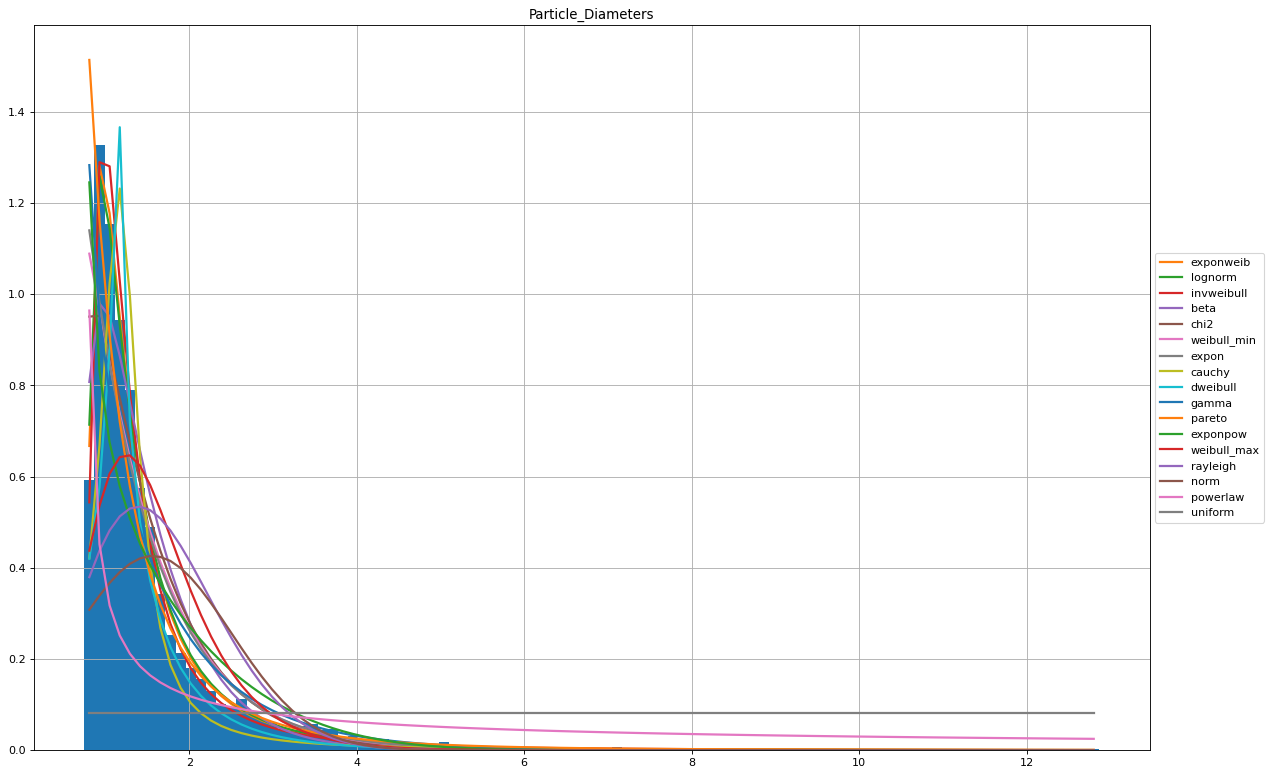

,sumsquare_error,aic,bic,kl_div,p_values
exponweib,0.018563,1067.447293,-53859.002775,inf,2.021139e-01
lognorm,0.032829,1085.263087,-51382.691666,inf,1.918031e-01
invweibull,0.034085,997.145830,-51219.068570,inf,4.112350e-02
beta,0.306348,1934.852642,-41641.169933,inf,2.038045e-16
weibull_min,0.586195,1505.577384,-38821.513072,inf,3.723905e-20
expon,0.630733,1450.026018,-38510.756627,inf,8.234207e-21
chi2,0.460613,1585.265218,-39872.203554,inf,8.277308e-25
gamma,0.937808,1245.231219,-36773.719048,inf,5.135572e-40
exponpow,1.204693,2395.839934,-35682.322724,inf,1.009054e-52
pareto,1.055158,992.771748,-36259.909524,inf,4.112481e-58


BEST: {'exponweib': {'a': 22.479761237778597, 'c': 0.3461595471159963, 'loc': 0.726939448417486, 'scale': 0.014062570051643037}}
exponweib  :  (22.479761237778597, 0.3461595471159963, 0.726939448417486, 0.014062570051643037) p_value: 0.20211394629952595
Particle_Diameters exponweib 0.20211394629952595
Minor_Axis_Size


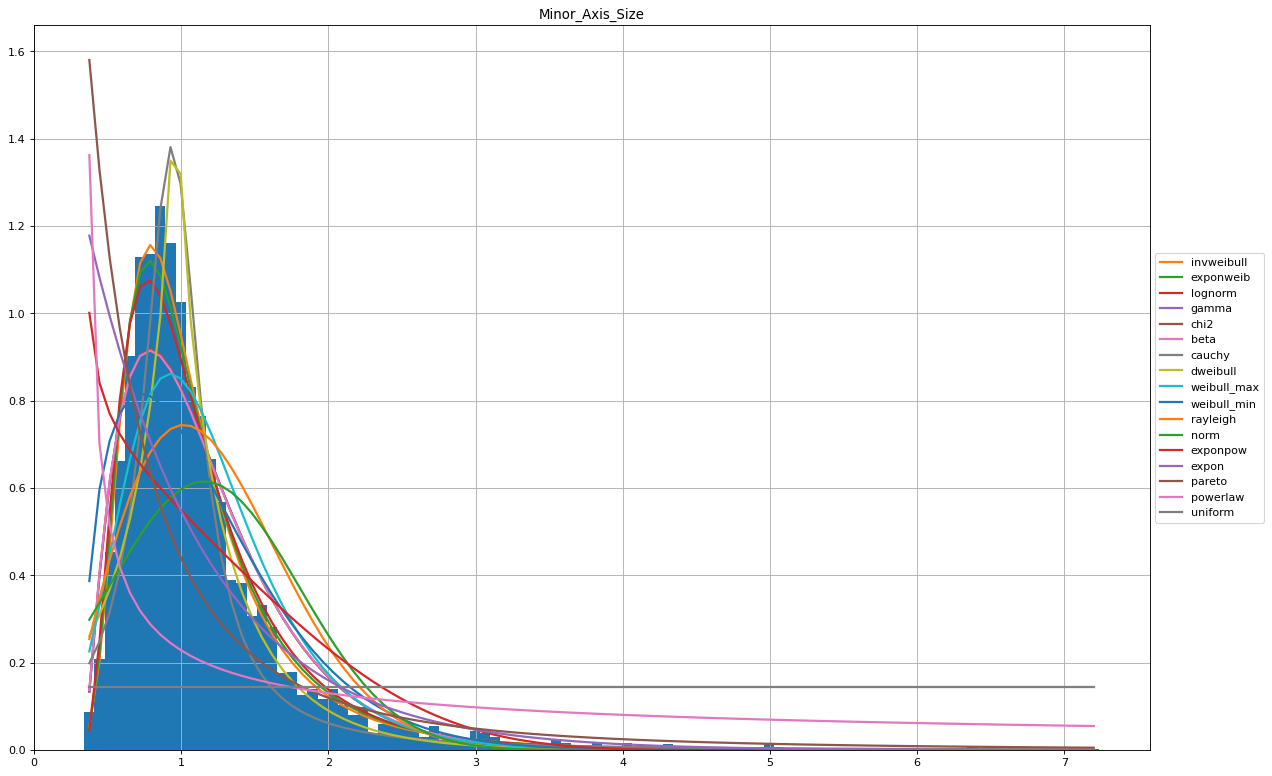

,sumsquare_error,aic,bic,kl_div,p_values
invweibull,0.070973,872.637549,-48022.806957,inf,1.975263e-01
exponweib,0.112543,923.050812,-46005.201651,inf,9.672224e-03
lognorm,0.180113,952.976803,-43964.259550,inf,1.683164e-04
chi2,0.529097,1231.593025,-39268.121927,inf,1.052627e-17
gamma,0.529084,1231.601069,-39268.225810,inf,1.047271e-17
beta,0.542687,1223.847293,-39149.218999,inf,3.298204e-18
weibull_min,1.146736,1326.489057,-35897.197008,inf,4.832662e-27
weibull_max,0.834240,1225.954687,-37283.708741,inf,3.483509e-37
dweibull,0.830966,1215.396133,-37300.844948,inf,1.995781e-61
cauchy,0.704402,820.563369,-38029.340801,inf,6.464694e-65


BEST: {'invweibull': {'c': 4.036880872353173, 'loc': -0.4601430613405307, 'scale': 1.3209570257120355}}
invweibull  :  (4.036880872353173, -0.4601430613405307, 1.3209570257120355) p_value: 0.19752634615113673
Minor_Axis_Size invweibull 0.19752634615113673
Major_Axis_Size


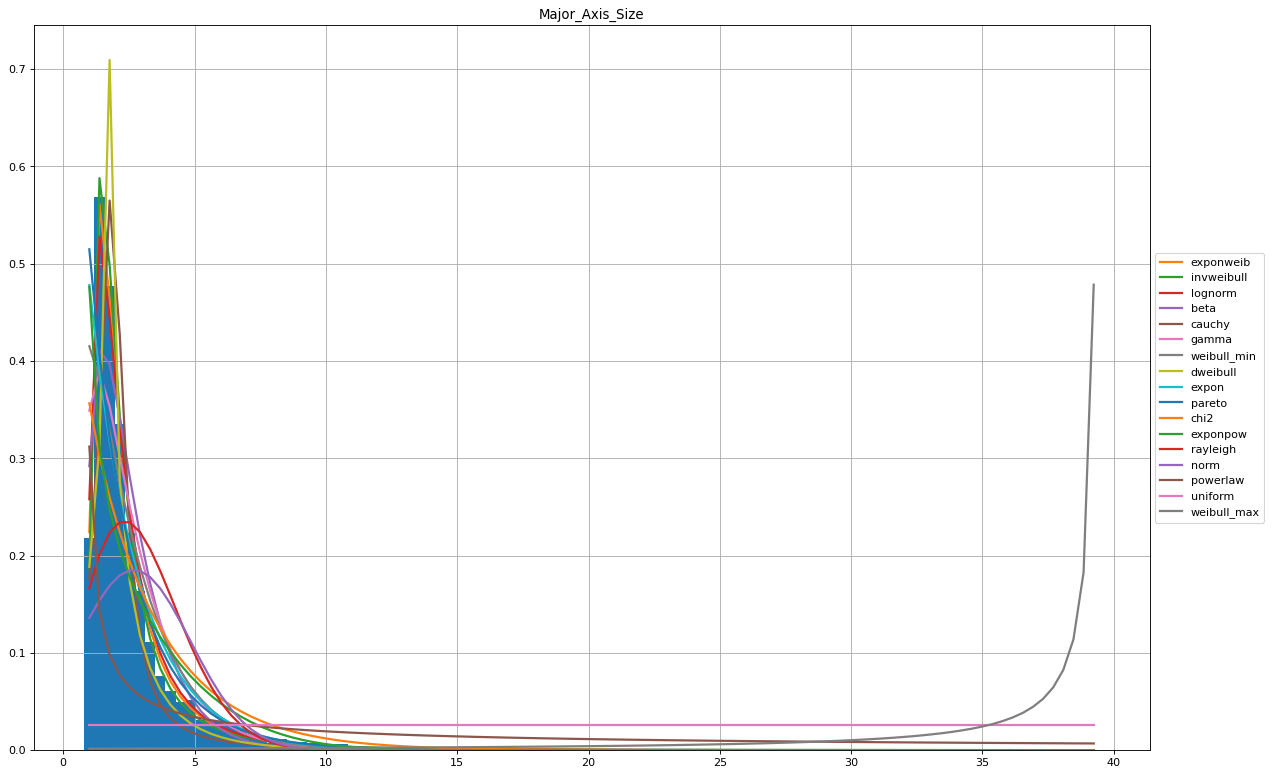

,sumsquare_error,aic,bic,kl_div,p_values
invweibull,0.002671,1360.352511,-62316.703202,inf,1.740944e-01
exponweib,0.001310,1496.502687,-65414.111331,inf,1.540641e-01
lognorm,0.006390,1579.494406,-58515.002902,inf,9.680070e-04
beta,0.052442,3301.893449,-49333.134052,inf,1.897593e-25
weibull_min,0.107282,2558.393450,-46222.250970,inf,1.585227e-27
gamma,0.077069,2650.302799,-47663.665507,inf,6.409409e-33
expon,0.135454,2176.688325,-45214.444551,inf,1.410186e-42
pareto,0.147540,1757.829293,-44833.592661,inf,1.433245e-54
exponpow,0.212990,4613.040916,-43233.589239,inf,2.433060e-84
cauchy,0.076374,1379.195012,-47711.527073,inf,3.016563e-117


BEST: {'exponweib': {'a': 46.926241334690886, 'c': 0.3215783278896328, 'loc': 0.7583341795753323, 'scale': 0.014277977691409413}}
invweibull  :  (1.8840782828913207, 0.3810099191102392, 1.3197045028913854) p_value: 0.17409441492041566
Major_Axis_Size invweibull 0.17409441492041566
Aspect_ratio


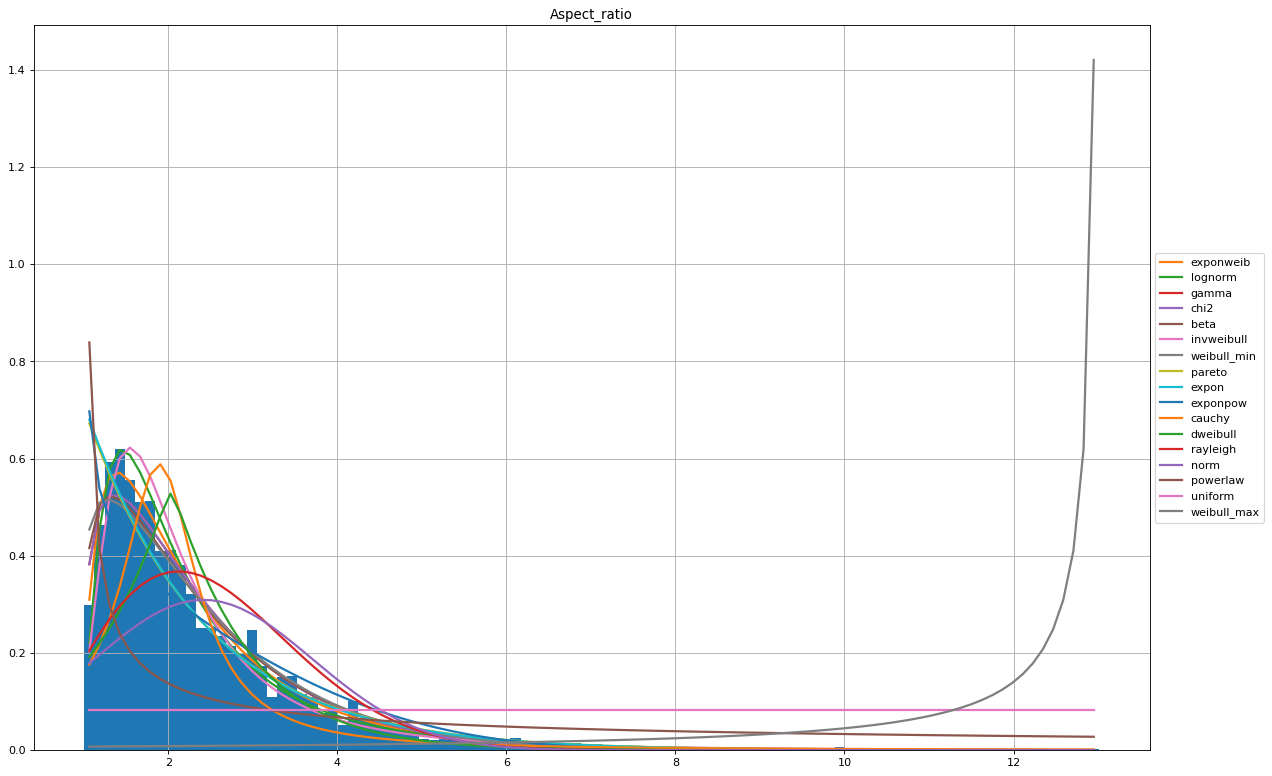

,sumsquare_error,aic,bic,kl_div,p_values
exponweib,0.021442,946.252241,-53230.786898,inf,4.705424e-01
lognorm,0.034740,879.267151,-51136.196127,inf,4.170441e-03
gamma,0.045566,1035.792460,-49953.957826,inf,2.009784e-03
chi2,0.045571,1035.768732,-49953.493069,inf,2.000273e-03
weibull_min,0.075392,1064.547439,-47759.538506,inf,2.336133e-04
beta,0.056918,998.494478,-48976.161393,inf,2.079449e-04
invweibull,0.074119,861.004576,-47833.743650,inf,5.105867e-06
pareto,0.218851,918.638807,-43115.289516,inf,3.454089e-16
expon,0.223939,924.382329,-43023.502515,inf,4.666877e-17
exponpow,0.324416,1448.158090,-41399.821363,inf,1.331719e-19


BEST: {'exponweib': {'a': 2.233297640620842, 'c': 0.7835127524232643, 'loc': 1.0011028111334235, 'scale': 0.7246954804548122}}
exponweib  :  (2.233297640620842, 0.7835127524232643, 1.0011028111334235, 0.7246954804548122) p_value: 0.47054240830650906
Aspect_ratio exponweib 0.47054240830650906
Circularity


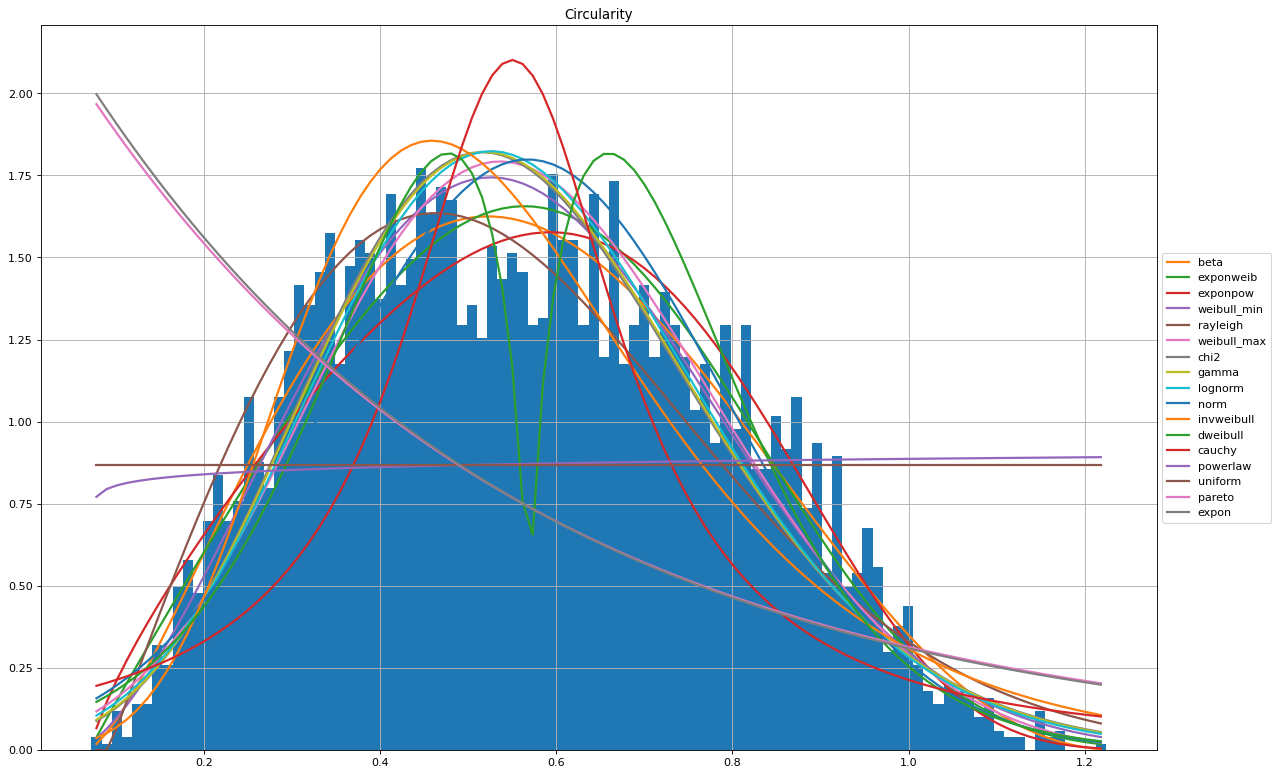

,sumsquare_error,aic,bic,kl_div,p_values
beta,2.148812,137.290209,-33152.012709,inf,1.358618e-01
weibull_min,3.267919,119.384943,-31333.351414,inf,4.058940e-03
exponweib,2.883344,125.090375,-31870.604496,inf,4.642243e-04
weibull_max,4.162448,123.440886,-30278.933364,inf,2.370439e-04
dweibull,6.222404,128.377885,-28526.786626,inf,1.250167e-04
lognorm,4.555261,117.191628,-29885.930871,inf,1.187928e-04
gamma,4.410403,116.473020,-30026.768110,inf,9.665044e-05
exponpow,3.051512,131.349590,-31631.945187,inf,9.031624e-05
chi2,4.375463,116.069283,-30061.429929,inf,7.513261e-05
norm,5.141391,124.412931,-29366.815252,inf,1.413176e-08


BEST: {'beta': {'a': 2.559070977237657, 'b': 3.4832538079098194, 'loc': 0.06586063272252754, 'scale': 1.1844927087472432}}
beta  :  (2.559070977237657, 3.4832538079098194, 0.06586063272252754, 1.1844927087472432) p_value: 0.13586183077267255
Circularity beta 0.13586183077267255


,Feature,PDF,p_value,loc,scale
0,Particle_Diameters,exponweib,0.202114,0.726939,0.014063
1,Minor_Axis_Size,invweibull,0.197526,-0.460143,1.320957
2,Major_Axis_Size,invweibull,0.174094,0.381010,1.319705
3,Aspect_ratio,exponweib,0.470542,1.001103,0.724695
4,Circularity,beta,0.135862,0.065861,1.184493


In [12]:
my_all_df= best_fit(path, carbon_type, df_all, my_distributions, num_dist)

# Spacing

In [13]:
new_path_spacing= path+'\\'+carbon_type+'\\'+'Stacked_Excel_File_C&D'
my_files_spacing= os.listdir(new_path_spacing)
my_files_spacing

['Stacked_file_C&D_61620B_TP.csv']

In [14]:
csv_file_spacing= my_files_spacing[0]

In [15]:
os.chdir(new_path_spacing)

In [16]:
df_spacing= pd.read_csv(csv_file_spacing)
df_spacing.drop(columns='Unnamed: 0', inplace=True)
df_spacing

,Pair Number,X1 coord,Y1 coord,X2 coord,Y2 coord,Spacing
0,1,0.270962,35.995268,6.811523,29.975586,8.889068
1,2,1.128374,94.851740,2.608421,98.855868,4.268909
2,3,1.545827,3.382241,8.942781,4.157624,7.437482
3,4,2.042259,54.733795,3.995366,50.051613,5.073209
4,5,2.109925,87.971776,6.688917,93.092162,6.869171
...,...,...,...,...,...,...
3041,89,89.890413,30.904595,97.044994,38.825163,10.673491
3042,90,97.068452,73.303571,98.104154,69.342511,4.094225
3043,91,99.619443,53.744161,99.691463,56.545799,2.802564
3044,92,99.679640,60.451601,99.691463,56.545799,3.905819


Pair Number


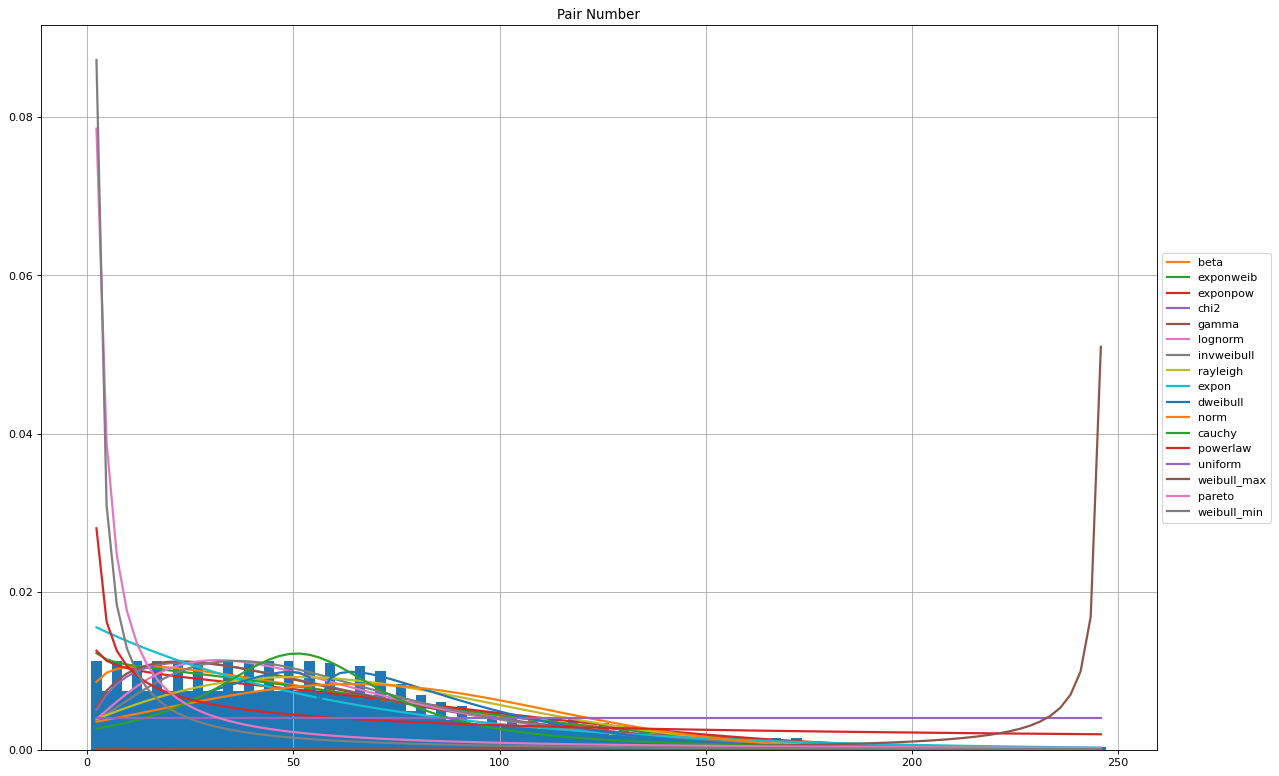

,sumsquare_error,aic,bic,kl_div,p_values
beta,0.000168,1240.553969,-50882.442154,0.031105,5.251410e-03
lognorm,0.000248,1245.898660,-49703.269323,0.042650,2.105561e-03
chi2,0.000201,1235.488702,-50343.865892,0.034278,1.474699e-03
invweibull,0.000264,1253.525492,-49511.379006,0.046341,8.650753e-04
exponweib,0.000170,1252.033447,-50835.396661,0.031193,1.220387e-04
gamma,0.000202,1236.244426,-50325.007375,0.034400,6.071909e-05
exponpow,0.000182,1240.607911,-50640.033162,0.035331,6.539924e-06
rayleigh,0.000320,1295.104035,-48924.943530,0.067142,4.548881e-13
norm,0.000490,1338.839858,-47631.103097,0.105713,2.547568e-23
expon,0.000378,1222.503529,-48419.715612,0.061074,7.005856e-29


BEST: {'beta': {'a': 1.1523124056526846, 'b': 4.536338168905935, 'loc': 0.8270428285929478, 'scale': 312.3985506345745}}
beta  :  (1.1523124056526846, 4.536338168905935, 0.8270428285929478, 312.3985506345745) p_value: 0.005251409766196581
Pair Number beta 0.005251409766196581
X1 coord


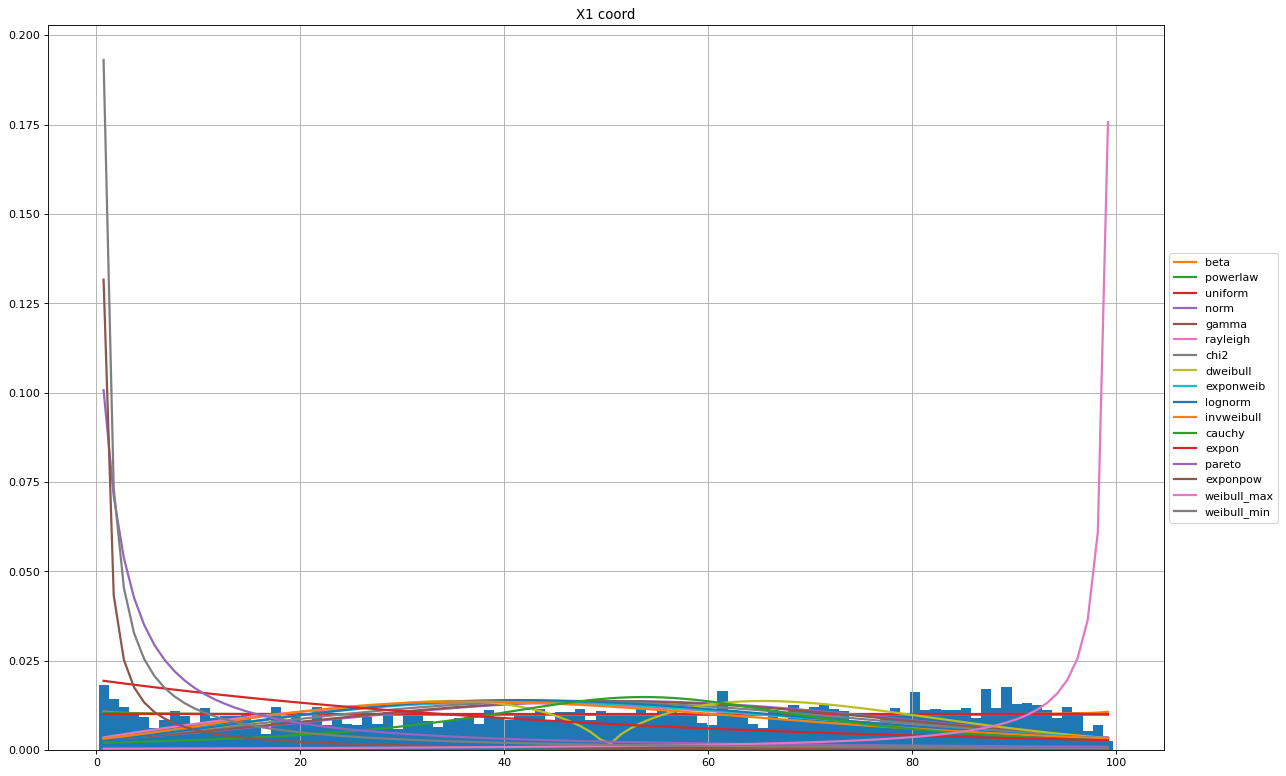

,sumsquare_error,aic,bic,kl_div,p_values
uniform,0.000697,924.009795,-46558.291867,0.036983,4.367662e-03
beta,0.000693,928.285968,-46557.980439,0.037463,3.060007e-03
powerlaw,0.000697,926.275417,-46551.852077,0.036979,1.104121e-03
dweibull,0.002256,960.252036,-42972.248481,0.124024,1.793710e-10
norm,0.002098,959.501247,-43201.658749,0.112317,1.672448e-12
gamma,0.002107,961.518729,-43181.130205,0.112639,4.054986e-13
chi2,0.002186,961.612699,-43068.942231,0.116752,4.866200e-17
exponweib,0.002325,966.379725,-42872.556058,0.125065,1.143451e-18
rayleigh,0.002137,954.654887,-43145.648083,0.112708,7.497659e-20
lognorm,0.002455,963.448664,-42714.762370,0.132497,5.191061e-22


BEST: {'beta': {'a': 0.977601489460305, 'b': 0.9781727924303888, 'loc': 0.20045230263157887, 'scale': 99.58477586840397}}
uniform  :  (0.2004523026315789, 99.48918810832733) p_value: 0.004367662244941747
X1 coord uniform 0.004367662244941747
Y1 coord


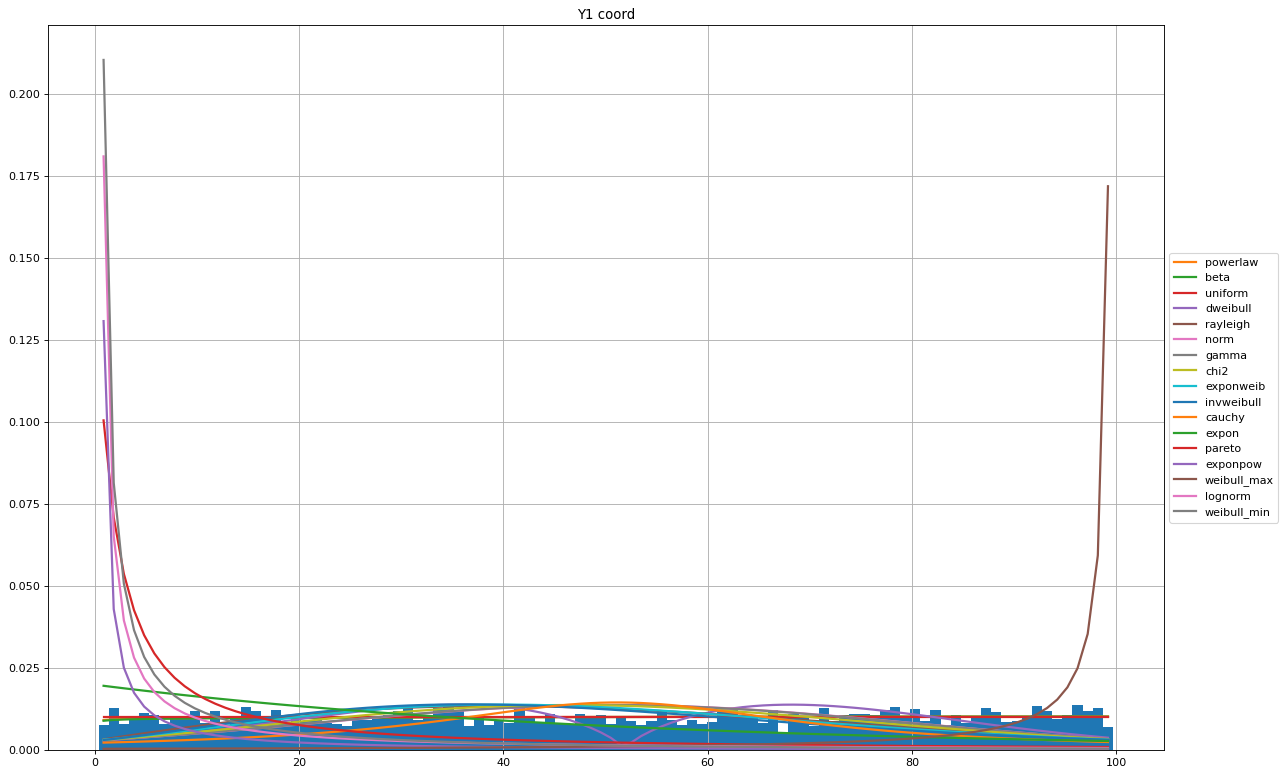

,sumsquare_error,aic,bic,kl_div,p_values
beta,0.000347,928.515713,-48663.908651,0.017625,5.190938e-01
powerlaw,0.000346,925.686362,-48679.742137,0.017589,2.676372e-01
uniform,0.000351,923.655018,-48650.808466,0.017779,7.372440e-02
dweibull,0.001667,960.501051,-43894.123221,0.098688,2.317121e-08
norm,0.001816,959.043592,-43640.817071,0.104001,5.010952e-13
gamma,0.001818,961.042020,-43630.480361,0.104065,2.776506e-13
chi2,0.001833,961.169848,-43604.757996,0.104829,1.019782e-15
rayleigh,0.001678,954.150986,-43882.658515,0.094591,5.325051e-17
exponweib,0.001913,966.181309,-43467.604650,0.109867,1.625666e-18
invweibull,0.001966,967.173288,-43391.086443,0.113596,3.224323e-20


BEST: {'powerlaw': {'a': 1.021335574304275, 'loc': 0.3568541493912196, 'scale': 99.31355606489478}}
beta  :  (1.026081863579948, 1.0018231065215162, 0.35651848595457647, 99.71359629004112) p_value: 0.5190937521419543
Y1 coord beta 0.5190937521419543
X2 coord


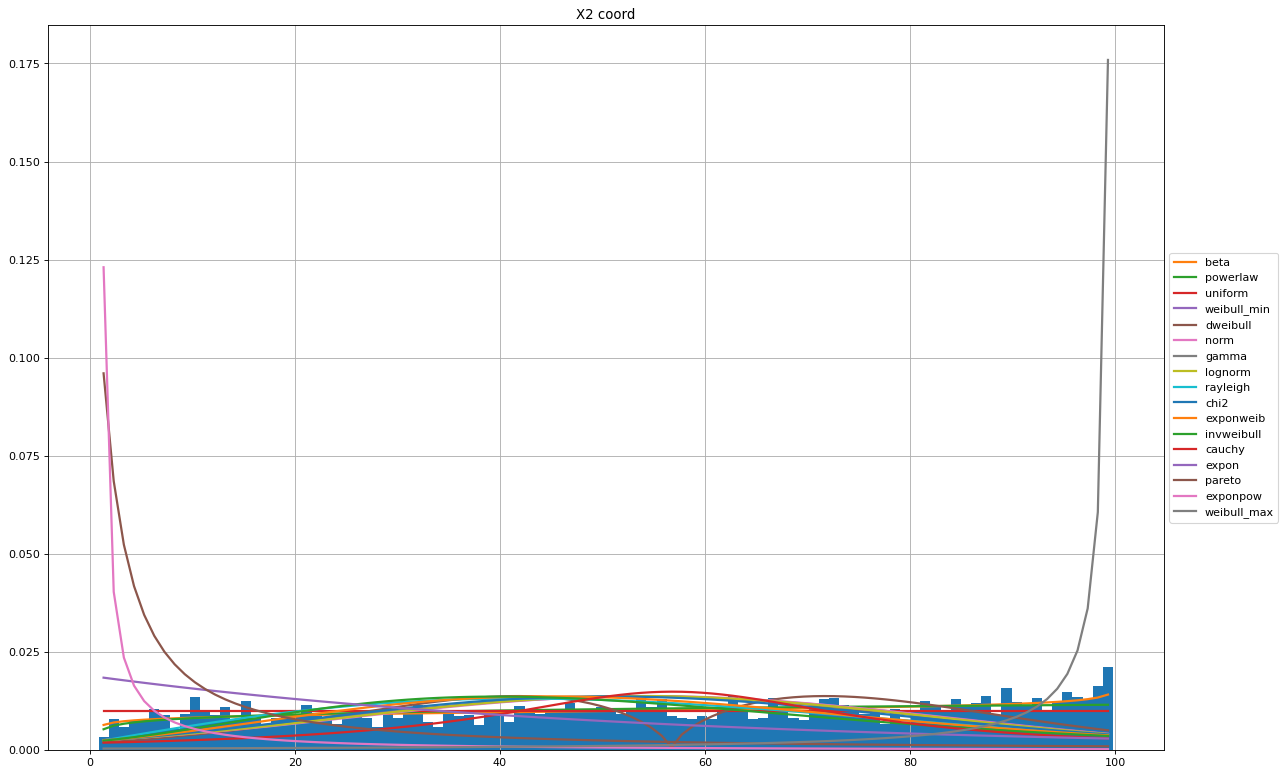

,sumsquare_error,aic,bic,kl_div,p_values
beta,0.000408,930.112616,-48173.854613,0.020374,6.353417e-01
powerlaw,0.000500,926.774090,-47561.188584,0.023635,5.420408e-03
uniform,0.000678,922.905761,-46643.047510,0.033565,3.352196e-10
weibull_min,0.002005,958.097114,-43331.785744,0.103967,2.903652e-12
norm,0.002084,960.256807,-43222.514271,0.109495,2.196751e-12
gamma,0.002099,962.220081,-43192.452822,0.110142,1.859816e-13
dweibull,0.002069,966.733894,-43235.448273,0.115022,1.618917e-13
lognorm,0.002102,962.083936,-43187.383329,0.110326,1.114800e-13
chi2,0.002152,962.259992,-43116.088609,0.112887,1.346072e-15
exponweib,0.002313,966.387515,-42888.046160,0.122005,2.352151e-19


BEST: {'beta': {'a': 1.0848689752128322, 'b': 0.9273675968689827, 'loc': 0.8483375918615539, 'scale': 99.35396983703967}}
beta  :  (1.0848689752128322, 0.9273675968689827, 0.8483375918615539, 99.35396983703967) p_value: 0.6353417201868403
X2 coord beta 0.6353417201868403
Y2 coord


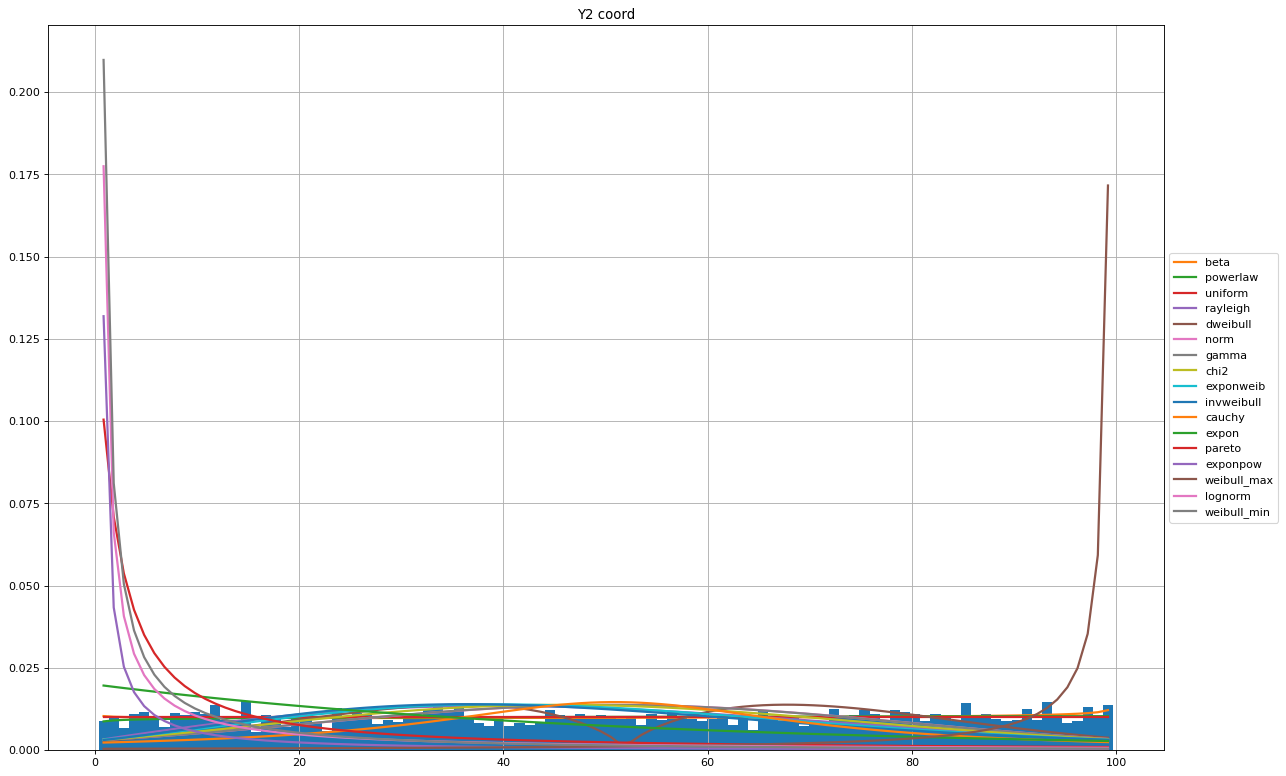

,sumsquare_error,aic,bic,kl_div,p_values
beta,0.000337,927.828074,-48753.081469,0.017203,7.551557e-01
powerlaw,0.000351,926.402763,-48643.342720,0.017763,3.104704e-01
uniform,0.000353,923.612008,-48628.686071,0.017980,1.068002e-01
dweibull,0.001794,960.344693,-43671.185012,0.104529,3.512505e-08
norm,0.001809,958.987865,-43653.133554,0.102395,6.524954e-13
gamma,0.001809,960.987167,-43644.992563,0.102411,4.697029e-13
chi2,0.001827,961.150216,-43615.607848,0.103819,5.022946e-16
rayleigh,0.001666,954.098835,-43904.229127,0.094223,2.235338e-16
exponweib,0.001903,966.303795,-43483.365829,0.109442,2.179809e-18
invweibull,0.001950,967.124179,-43416.773833,0.113137,4.565858e-20


BEST: {'beta': {'a': 0.9815968256770418, 'b': 0.9512862912404166, 'loc': 0.3875248015873015, 'scale': 99.29473231969016}}
beta  :  (0.9815968256770418, 0.9512862912404166, 0.3875248015873015, 99.29473231969016) p_value: 0.7551557434962418
Y2 coord beta 0.7551557434962418
Spacing


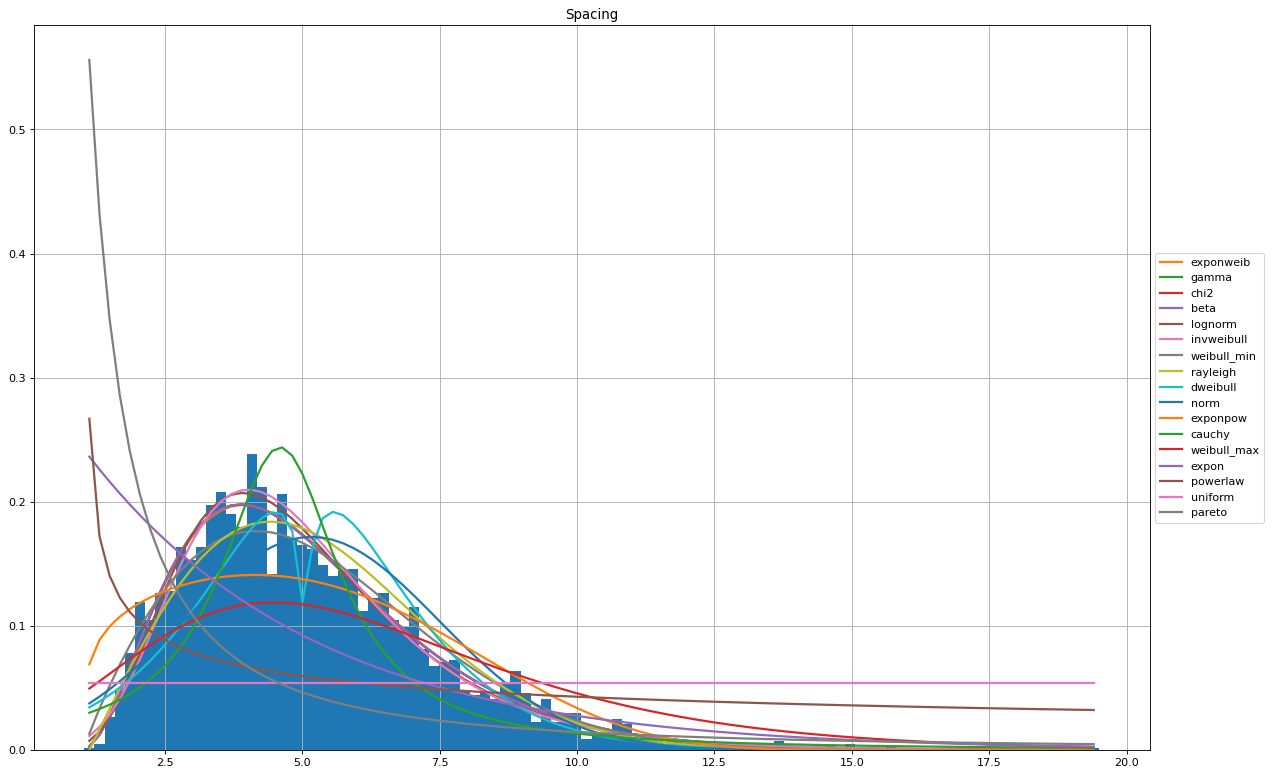

,sumsquare_error,aic,bic,kl_div,p_values
gamma,0.011318,924.871692,-38059.927183,inf,9.579762e-01
chi2,0.011318,924.874758,-38059.913651,inf,9.579077e-01
beta,0.011318,926.876050,-38051.886206,inf,9.578981e-01
exponweib,0.011260,929.682901,-38067.569705,inf,9.560515e-01
lognorm,0.013466,885.958540,-37530.581283,inf,2.963530e-01
invweibull,0.015155,887.271866,-37170.726502,inf,1.317712e-01
weibull_min,0.017338,1042.089034,-36760.761191,inf,2.300387e-02
rayleigh,0.020654,inf,-36235.769091,inf,7.087155e-08
dweibull,0.055939,1101.234197,-33192.798483,inf,1.169413e-09
exponpow,0.067236,1413.742303,-32632.512311,inf,1.101122e-11


BEST: {'exponweib': {'a': 2.2819243256897535, 'c': 1.2716190138843255, 'loc': 0.9769381206146808, 'scale': 3.004494811700634}}
gamma  :  (3.2773851934865146, 0.9507896499142231, 1.287694479619942) p_value: 0.9579761699648068
Spacing gamma 0.9579761699648068


,Feature,PDF,p_value,loc,scale
0,Pair Number,beta,0.005251,0.827043,312.398551
1,X1 coord,uniform,0.004368,0.200452,99.489188
2,Y1 coord,beta,0.519094,0.356518,99.713596
3,X2 coord,beta,0.635342,0.848338,99.353970
4,Y2 coord,beta,0.755156,0.387525,99.294732
5,Spacing,gamma,0.957976,0.950790,1.287694


In [17]:
my_spacing_df= best_fit(path, carbon_type, df_spacing, my_distributions, num_dist)
my_spacing_df= my_spacing_df.iloc[[5]].copy()

In [18]:
my_spacing_df

,Feature,PDF,p_value,loc,scale
5,Spacing,gamma,0.957976,0.95079,1.287694


# Orientation

In [34]:
new_path_ori= path+'\\'+carbon_type+'\\'+'Stacked_Excel_File_MA_AR_New'
my_files_ori= os.listdir(new_path_ori)
my_files_ori

['Stacked_MA_AR_Cir_63020A_IP.csv']

In [35]:
os.chdir(new_path_ori)

In [36]:
df_ori= pd.read_csv(my_files_ori[0])
df_ori.drop(columns='Unnamed: 0', inplace=True)
df_ori

,Particle_Diameters,Minor_Axis_Size,Major_Axis_Size,Aspect_ratio,Circularity,Orientation
0,1.445171,1.055640,3.226157,3.056115,0.438421,9.935742
1,12.226986,7.616082,22.908035,3.007850,0.521705,14.310373
2,3.186091,2.880514,3.675686,1.276052,0.925878,-41.896958
3,1.870042,1.635240,2.281960,1.395490,0.954384,-48.797674
4,2.332352,1.725465,3.290203,1.906851,0.860906,87.507483
...,...,...,...,...,...,...
1417,1.882984,1.090727,4.129731,3.786220,0.411799,22.982329
1418,1.411162,0.860599,2.610474,3.033323,0.695526,75.730852
1419,2.616945,1.699772,4.602933,2.707970,0.615610,-22.173439
1420,1.749264,1.361858,2.372898,1.742397,0.869761,-39.346864


Particle_Diameters


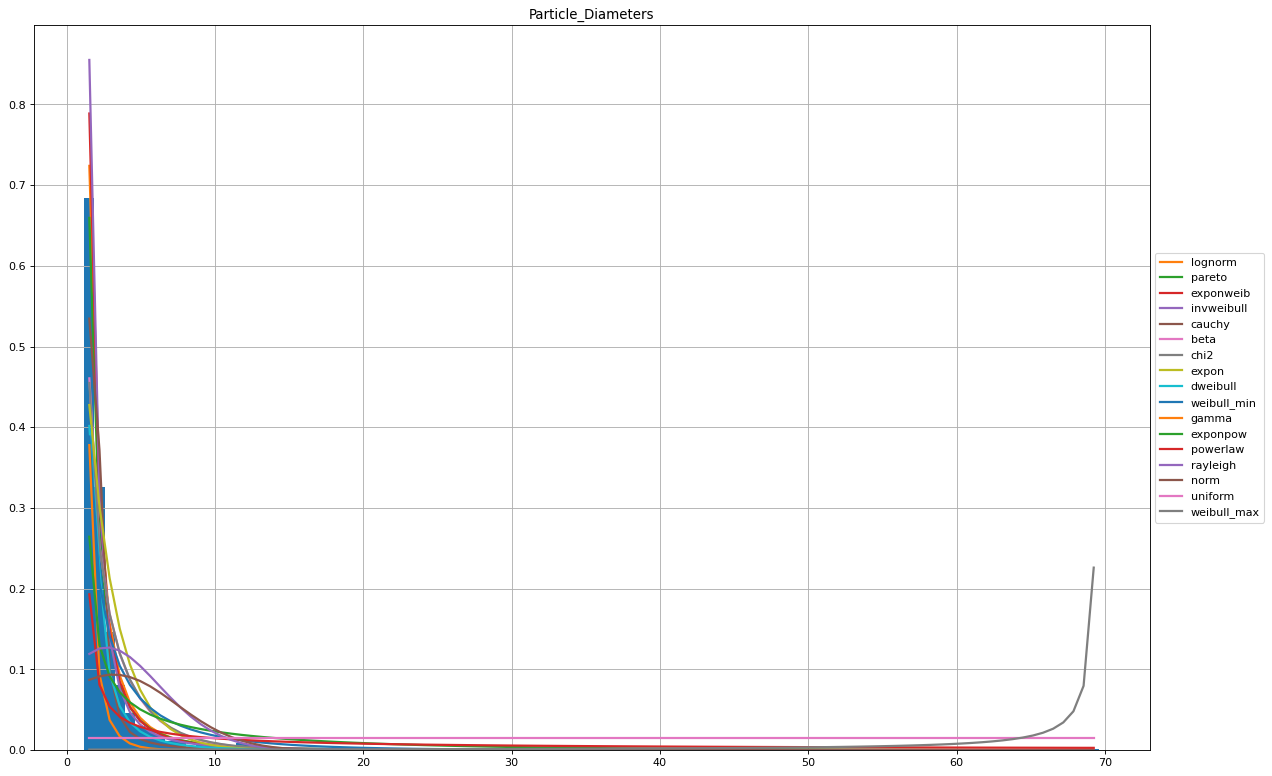

,sumsquare_error,aic,bic,kl_div,p_values
invweibull,0.029671,1511.369985,-15303.692939,inf,5.204654e-01
exponweib,0.011594,1621.584206,-16632.623767,inf,3.928145e-01
lognorm,0.002651,1704.462471,-18738.336342,inf,6.932807e-02
pareto,0.004512,1511.292288,-17981.952383,inf,2.004177e-12
beta,0.061307,2820.389877,-14264.447517,inf,3.822671e-23
chi2,0.064464,2739.443174,-14200.303504,inf,1.565688e-25
expon,0.082667,3619.068911,-13853.903243,inf,2.203804e-47
cauchy,0.029695,1670.552890,-15309.783470,inf,5.047471e-55
weibull_min,0.107938,1521.842574,-13467.334273,inf,1.376827e-64
dweibull,0.094458,2218.135998,-13657.039075,inf,2.574710e-73


BEST: {'lognorm': {'s': 1.2377356815940135, 'loc': 1.1786702111352116, 'scale': 0.8262066978524149}}
invweibull  :  (1.2089053402443666, 1.046457349214904, 0.6524132863531555) p_value: 0.520465439547741
Particle_Diameters invweibull 0.520465439547741
Minor_Axis_Size


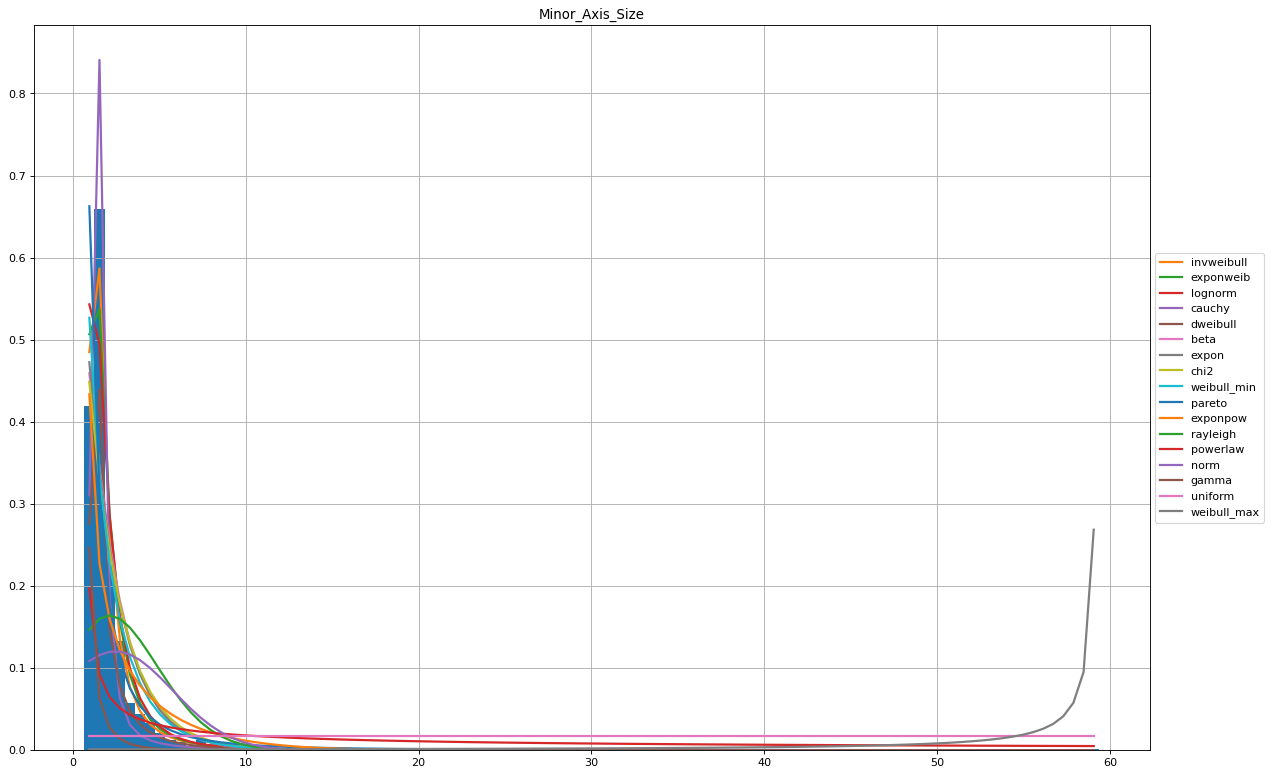

,sumsquare_error,aic,bic,kl_div,p_values
invweibull,0.012211,1647.107543,-16566.223976,inf,1.324497e-03
exponweib,0.028564,1945.670519,-15350.515309,inf,4.591203e-09
lognorm,0.049429,2059.995803,-14577.955146,inf,6.510283e-12
expon,0.116457,3388.042932,-13366.575266,inf,3.790680e-33
weibull_min,0.124452,2915.001949,-13264.902055,inf,2.340497e-35
cauchy,0.053512,1650.947139,-14472.341667,inf,7.309222e-36
beta,0.114552,3626.159326,-13375.506595,inf,7.598990e-37
chi2,0.123710,3195.662910,-13273.404651,inf,9.455594e-43
dweibull,0.078379,2275.908832,-13922.388025,inf,5.875317e-68
pareto,0.182186,1402.115416,-12722.963239,inf,4.211423e-70


BEST: {'invweibull': {'c': 1.798463805373518, 'loc': 0.4331090427414479, 'scale': 0.9620140378069499}}
invweibull  :  (1.798463805373518, 0.4331090427414479, 0.9620140378069499) p_value: 0.0013244969028775961
Minor_Axis_Size invweibull 0.0013244969028775961
Major_Axis_Size


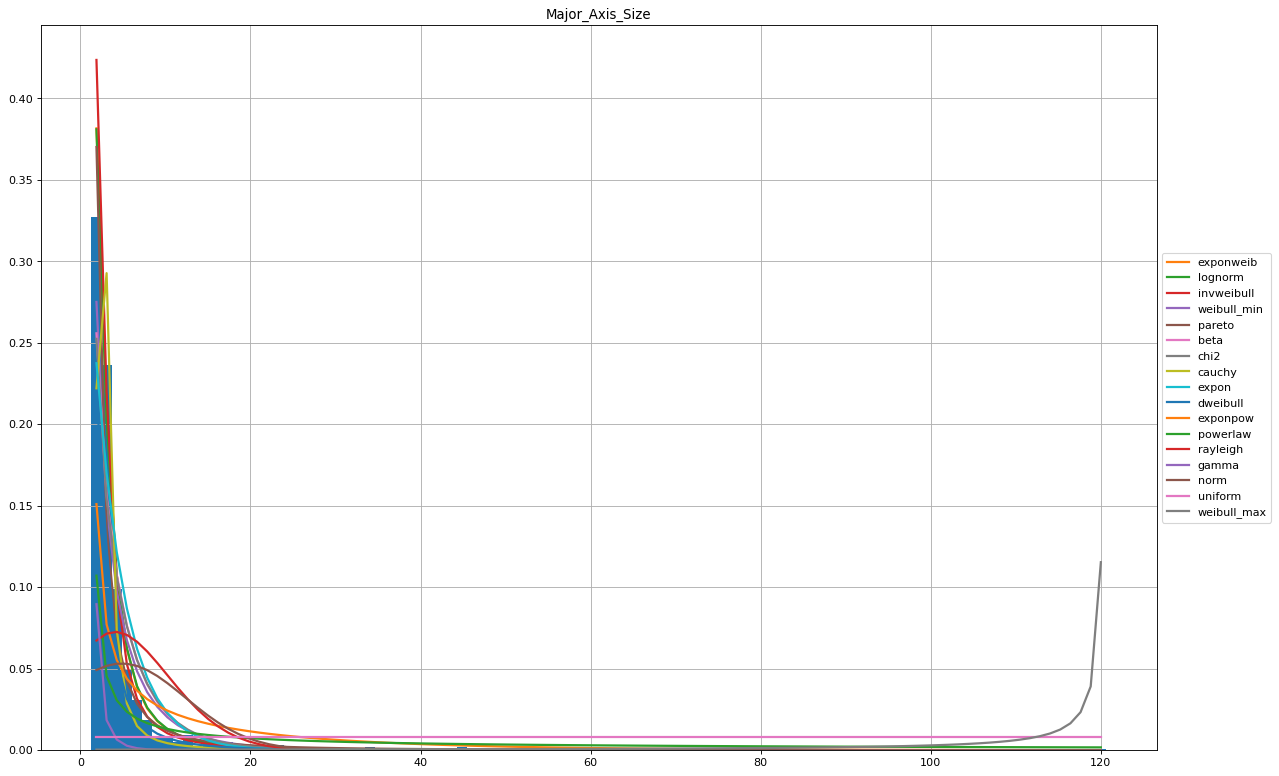

,sumsquare_error,aic,bic,kl_div,p_values
invweibull,0.009664,1684.049149,-16898.871632,inf,8.999984e-01
exponweib,0.004299,1899.884815,-18043.290973,inf,7.928092e-04
lognorm,0.004605,1927.885360,-17952.821289,inf,6.569254e-04
weibull_min,0.011823,2395.058453,-16612.054936,inf,4.611449e-19
beta,0.014210,3239.715324,-16343.296621,inf,4.979567e-28
chi2,0.015183,3075.030559,-16256.420483,inf,2.628867e-30
cauchy,0.015745,1774.113509,-16211.965132,inf,4.801682e-41
expon,0.017041,3606.733838,-16099.526696,inf,9.552608e-43
pareto,0.012756,1510.579559,-16504.075390,inf,2.759093e-45
dweibull,0.026856,2204.177387,-15445.410880,inf,2.588001e-79


BEST: {'exponweib': {'a': 23.445429300187087, 'c': 0.306163307647495, 'loc': 1.2576197545570071, 'scale': 0.02836714262385985}}
invweibull  :  (1.451058112411491, 0.918090913765284, 1.5157892504417751) p_value: 0.8999983716985643
Major_Axis_Size invweibull 0.8999983716985643
Aspect_ratio


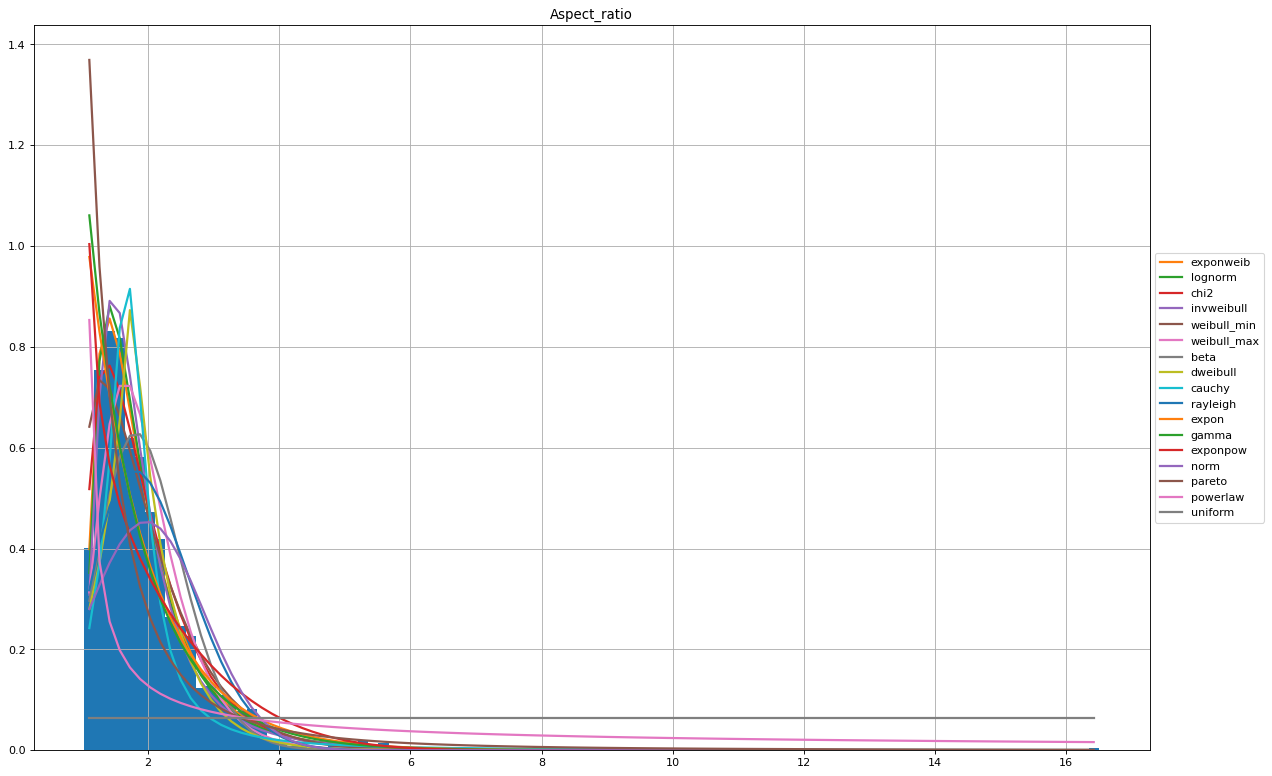

,sumsquare_error,aic,bic,kl_div,p_values
exponweib,0.014950,1581.272545,-16271.157715,inf,9.912028e-01
lognorm,0.020449,1418.471757,-15833.001907,inf,7.297449e-01
invweibull,0.043971,1267.122967,-14744.333919,inf,2.026731e-01
chi2,0.041978,2196.249907,-14810.285935,inf,1.177325e-01
weibull_min,0.114170,2466.163267,-13387.517858,inf,1.364673e-02
weibull_max,0.175171,2719.576834,-12778.794611,inf,1.057766e-05
beta,0.403327,5596.184742,-11585.610311,inf,5.367415e-13
expon,0.471355,1634.595510,-11378.491411,inf,6.909734e-15
gamma,0.580180,1689.921968,-11075.844324,inf,2.776621e-20
exponpow,0.678643,3712.030138,-10852.937363,inf,3.804384e-22


BEST: {'exponweib': {'a': 4.251508120412938, 'c': 0.6927884482558541, 'loc': 0.9946288363006923, 'scale': 0.2975451988874266}}
exponweib  :  (4.251508120412938, 0.6927884482558541, 0.9946288363006923, 0.2975451988874266) p_value: 0.9912028103299435
Aspect_ratio exponweib 0.9912028103299435
Circularity


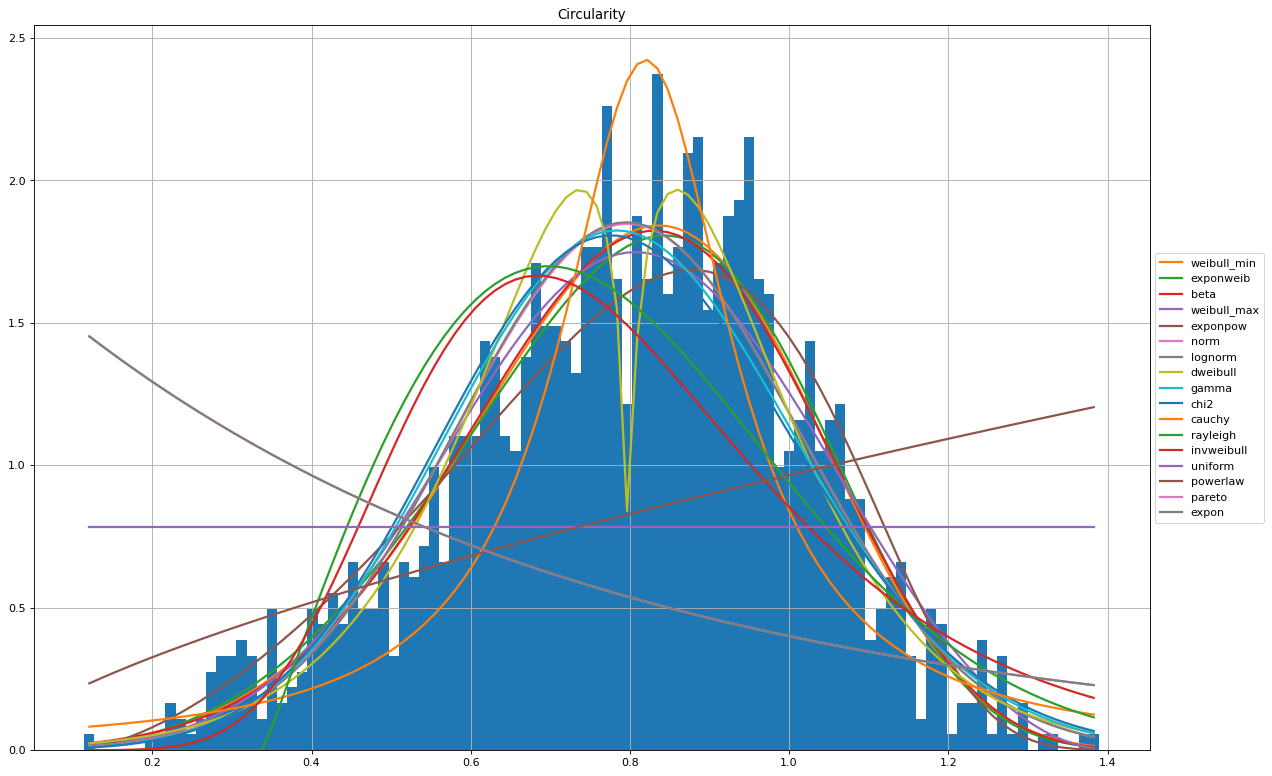

,sumsquare_error,aic,bic,kl_div,p_values
weibull_min,3.686233,180.052809,-8446.535586,inf,8.827650e-01
exponweib,3.728823,185.538595,-8422.940616,inf,8.599060e-01
beta,3.804089,182.816445,-8394.523191,inf,7.767217e-01
weibull_max,4.618187,180.281754,-8126.020988,inf,2.259265e-01
exponpow,4.747423,190.665699,-8086.774108,inf,5.526247e-02
norm,4.807439,175.852882,-8076.170000,inf,3.880134e-02
lognorm,4.872147,179.704818,-8049.897747,inf,3.580264e-02
dweibull,5.099744,174.953846,-7984.975313,inf,2.423990e-02
gamma,5.509248,177.561867,-7875.143205,inf,4.126887e-03
chi2,5.954582,177.083704,-7764.606986,inf,1.116015e-03


BEST: {'weibull_min': {'c': 5.022126130045816, 'loc': -0.1442964471140541, 'scale': 1.0247822512529954}}
weibull_min  :  (5.022126130045816, -0.1442964471140541, 1.0247822512529954) p_value: 0.8827650096964822
Circularity weibull_min 0.8827650096964822
Orientation


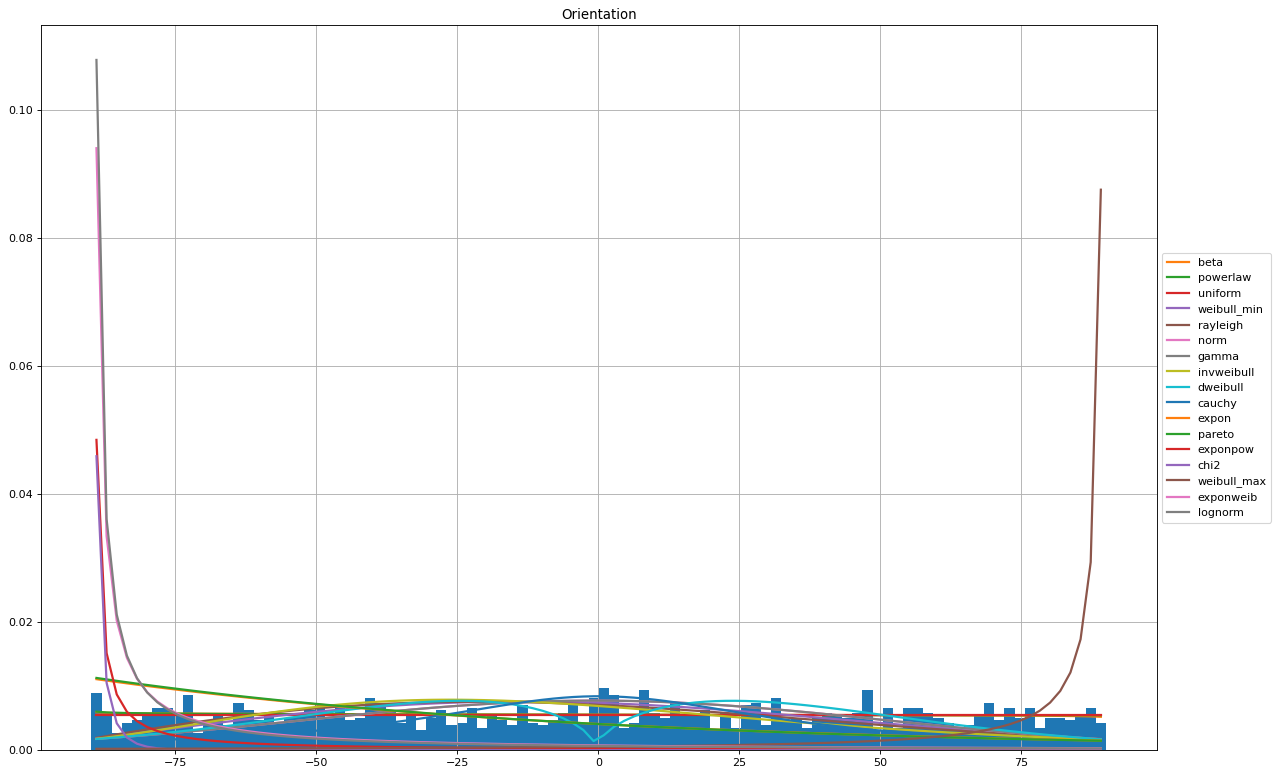

,sumsquare_error,aic,bic,kl_div,p_values
uniform,0.000244,1042.399493,-22136.160732,0.039541,8.312253e-01
powerlaw,0.000243,1044.453261,-22134.811917,0.039491,6.500359e-01
beta,0.000243,1046.458792,-22129.730797,0.039455,5.450563e-01
dweibull,0.000714,1079.311570,-20603.445803,0.129262,2.487647e-03
weibull_min,0.000579,1074.551788,-20901.995892,0.105968,2.703255e-05
norm,0.000612,1077.716916,-20830.065766,0.114104,9.194161e-06
gamma,0.000612,1079.717012,-20822.505421,0.114129,9.103373e-06
rayleigh,0.000579,1072.843932,-20908.646682,0.105657,3.102748e-06
invweibull,0.000672,1085.865973,-20689.955640,0.124938,3.165181e-08
cauchy,0.000932,1135.795652,-20232.512932,0.188860,2.462069e-20


BEST: {'beta': {'a': 0.9876850257182921, 'b': 1.0119445592081917, 'loc': -89.85617869525514, 'scale': 179.83775799876815}}
uniform  :  (-89.85617869525512, 179.82739377596386) p_value: 0.8312252968124483
Orientation uniform 0.8312252968124483


,Feature,PDF,p_value,loc,scale
0,Particle_Diameters,invweibull,0.520465,1.046457,0.652413
1,Minor_Axis_Size,invweibull,0.001324,0.433109,0.962014
2,Major_Axis_Size,invweibull,0.899998,0.918091,1.515789
3,Aspect_ratio,exponweib,0.991203,0.994629,0.297545
4,Circularity,weibull_min,0.882765,-0.144296,1.024782
5,Orientation,uniform,0.831225,-89.856179,179.827394


In [37]:
my_ori_df= best_fit(path, carbon_type, df_ori, my_distributions, num_dist)
my_ori_df= my_ori_df.iloc[[5]].copy()

In [38]:
my_ori_df

,Feature,PDF,p_value,loc,scale
5,Orientation,uniform,0.831225,-89.856179,179.827394


In [24]:
my_final_df= pd.concat([my_all_df,my_spacing_df,my_ori_df], axis=0)
my_final_df.reset_index(inplace=True)
my_final_df.drop(columns=['index'], inplace=True)

In [25]:
os.chdir(path+'\\'+carbon_type+'\\'+"Goodness_of_fit_3")

In [26]:
my_final_df

,Feature,PDF,p_value,loc,scale
0,Particle_Diameters,exponweib,2.021139e-01,0.726939,0.014063
1,Minor_Axis_Size,invweibull,1.975263e-01,-0.460143,1.320957
2,Major_Axis_Size,invweibull,1.740944e-01,0.381010,1.319705
3,Aspect_ratio,exponweib,4.705424e-01,1.001103,0.724695
4,Circularity,beta,1.358618e-01,0.065861,1.184493
5,Spacing,gamma,9.579762e-01,0.950790,1.287694
6,Orientation,dweibull,1.222564e-20,0.303881,67.516176


In [33]:
# my_final_df.to_csv(carbon_type+"_"+'final_df.csv')